### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold


### Read files & submission file for template

In [5]:
X_train = pd.read_csv('Data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('Data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('Data/y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('sample_submission.csv',index_col='ROW_ID')

In [6]:
X_train.columns

Index(['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16',
       'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9',
       'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1',
       'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP'],
      dtype='str')

### Features

In [7]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [8]:
for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    X_train[ f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    X_train[ f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    X_test[ f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(1)
    X_test[ f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')


/var/folders/42/4qk9d5xn1zb22gk9hbqpxdwh0000gn/T/ipykernel_99631/2202369803.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
/var/folders/42/4qk9d5xn1zb22gk9hbqpxdwh0000gn/T/ipykernel_99631/2202369803.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
/var/folders/42/4qk9d5xn1zb22gk9hbqpxdwh0000gn/T/ipykernel_99631/2202369803.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
/var/folders/42/4qk9d5xn1zb22gk9hbqpxdwh0000gn/T/ipykernel_99631/2202369803.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
/var/folders/42/4qk9d5xn1zb22gk9

In [9]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'STD_PERF_{i}' for i in [20]]
features = features + [ f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]

### Fitting one simple Ridge

In [10]:
new_ridge = linear_model.Ridge(alpha=1)

new_ridge.fit(X_train[features].to_numpy(na_value=0),y_train.to_numpy(na_value=0))

preds_ridge = pd.DataFrame(new_ridge.predict(X_test[features].fillna(0).to_numpy(na_value=0)), index = sample_submission.index,columns=['target'])

In [11]:
(preds_ridge>0).astype(int).to_csv('preds_ridge_bench.csv')

### Fitting a lightgbm using cross validation

In [12]:
features_lgbm = features

In [13]:

# A quite large number of trees with low depth to prevent overfits
lgbm_params = {
                "objective": "mse",
                "metric": "mse",
                "num_threads": 50,
                "seed": 42,
                "verbosity": -1,
                'learning_rate': 1e-2,
                'max_depth': 3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
test_dates = X_test['TS'].unique()

n_splits = 8
scores_lgbm = []
models_lgbm = []
 
splits = KFold(n_splits=n_splits, random_state=0,
               shuffle=True,).split(train_dates)

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids,[x for x in features_lgbm ]] 
    y_local_train = y_train.loc[local_train_ids,'target']
    
    X_local_test = X_train.loc[local_test_ids,[x for x in features_lgbm ]] 
    y_local_test = y_train.loc[local_test_ids,'target']
    
    X_local_train = X_local_train
    X_local_test = X_local_test

    train_data = lgbm.Dataset(X_local_train, label=y_local_train.values) 
    
    model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
    
    y_local_pred = model_lgbm.predict(X_local_test.values, num_threads = lgbm_params['num_threads'])
    
    
    models_lgbm.append(model_lgbm)
    score = accuracy_score((y_local_test>0).astype(int),
                (y_local_pred>0).astype(int))
    scores_lgbm.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores_lgbm)*100
std = np.std(scores_lgbm)*100

u = (mean + std)
l = (mean - std)

print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')


Fold 1 - Accuracy: 51.95%
Fold 2 - Accuracy: 52.45%
Fold 3 - Accuracy: 52.18%
Fold 4 - Accuracy: 52.10%
Fold 5 - Accuracy: 51.97%
Fold 6 - Accuracy: 52.48%
Fold 7 - Accuracy: 52.45%
Fold 8 - Accuracy: 52.17%
Accuracy: 52.22% [52.02 ; 52.42] (+- 0.20)


/var/folders/42/4qk9d5xn1zb22gk9hbqpxdwh0000gn/T/ipykernel_99631/3401225653.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]


<Axes: >

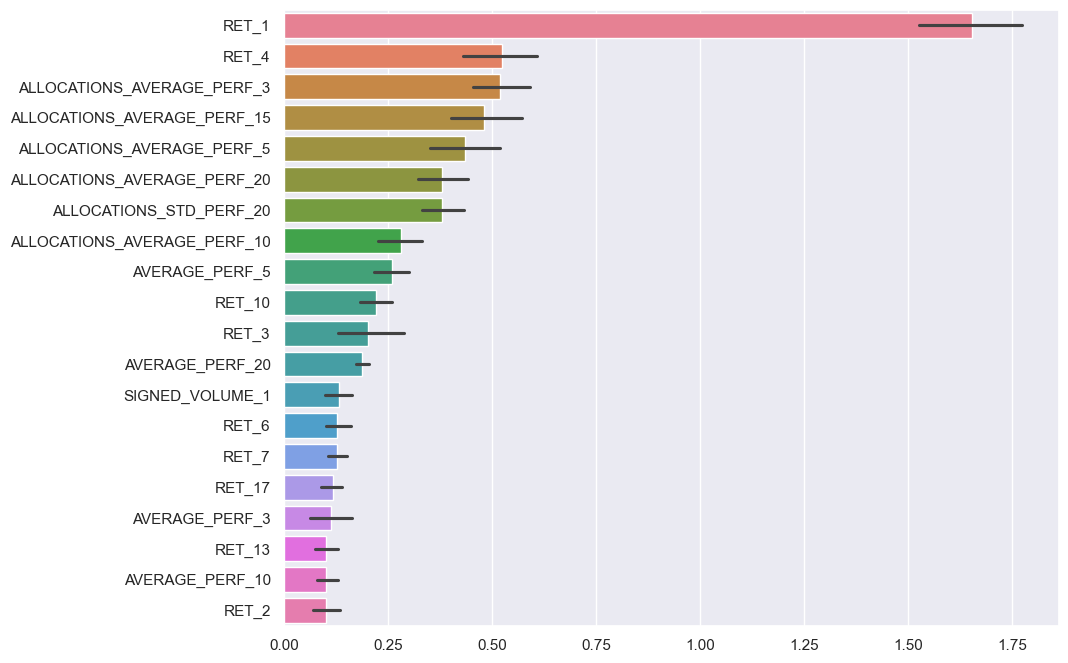

In [14]:
feature_importances = pd.DataFrame([model_lgbm.feature_importance(importance_type='gain') for model_lgbm in models_lgbm], columns=features_lgbm)

feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]

plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)


In [15]:
train_data = lgbm.Dataset(X_train[features_lgbm], label=y_train) 

model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
preds_lgbm = model_lgbm.predict(X_test[features_lgbm])
preds_lgbm = pd.DataFrame(preds_lgbm, index=sample_submission.index,columns=['target']) 


In [16]:
(preds_lgbm>0).astype(int).to_csv('preds_lgbm_bench.csv')

In [18]:
"""
Optimisation LightGBM avec Optuna
Challenge: Prédiction des Performances d'Allocations d'Actifs
"""

import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

# Nombre de trials pour l'optimisation
N_TRIALS = 100  # Augmenter à 200-500 pour une optimisation plus fine

# Nombre de folds pour la validation croisée temporelle
N_SPLITS = 5

# Seed pour reproductibilité
RANDOM_SEED = 42

print("="*80)
print("OPTIMISATION LIGHTGBM AVEC OPTUNA")
print("="*80)

# ============================================================================
# CHARGEMENT DES DONNÉES (à adapter selon vos chemins)
# ============================================================================

# X_train = pd.read_csv('path/to/X_train.csv')
# y_train = pd.read_csv('path/to/y_train.csv')
# X_test = pd.read_csv('path/to/X_test.csv')
# sample_submission = pd.read_csv('path/to/sample_submission.csv')

# Exemple avec vos données
# features_lgbm = [col for col in X_train.columns if col not in ['ROW_ID', 'TS', 'ALLOCATION']]

# ============================================================================
# FONCTION OBJECTIVE POUR OPTUNA
# ============================================================================

def objective(trial):
    """
    Fonction objective à optimiser par Optuna.
    Retourne l'accuracy moyenne sur la validation croisée temporelle.
    """
    
    # === HYPERPARAMÈTRES À OPTIMISER ===
    params = {
        # Paramètres d'arbre
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': RANDOM_SEED,
        
        # Complexité du modèle
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 500),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-5, 1e2, log=True),
        
        # Apprentissage
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        
        # Régularisation
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),  # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),  # L2
        
        # Sous-échantillonnage
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 10),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        
        # Performance
        'min_split_gain': trial.suggest_float('min_split_gain', 1e-8, 1.0, log=True),
        
        # Pour éviter l'overfitting sur signaux faibles
        'path_smooth': trial.suggest_float('path_smooth', 0.0, 100.0),
    }
    
    # === VALIDATION CROISÉE TEMPORELLE ===
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    cv_scores = []
    
    # Trier les données par timestamp pour respecter l'ordre temporel
    # Adapter selon votre structure de données
    # Si vous avez une colonne TS, triez d'abord :
    # sort_idx = X_train.sort_values('TS').index
    # X_sorted = X_train.loc[sort_idx]
    # y_sorted = y_train.loc[sort_idx]
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        # Séparation train/validation
        X_tr = X_train.iloc[train_idx][features_lgbm]
        y_tr = y_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx][features_lgbm]
        y_val = y_train.iloc[val_idx]
        
        # Création des datasets LightGBM
        train_data = lgbm.Dataset(X_tr, label=(y_tr > 0).astype(int))
        val_data = lgbm.Dataset(X_val, label=(y_val > 0).astype(int), reference=train_data)
        
        # Entraînement avec early stopping
        model = lgbm.train(
            params,
            train_data,
            valid_sets=[train_data, val_data],
            valid_names=['train', 'valid'],
            callbacks=[
                lgbm.early_stopping(stopping_rounds=50, verbose=False),
                lgbm.log_evaluation(period=0)  # Pas d'affichage
            ]
        )
        
        # Prédiction et calcul de l'accuracy
        y_pred_proba = model.predict(X_val)
        y_pred = (y_pred_proba > 0.5).astype(int)
        y_true = (y_val > 0).astype(int)
        
        fold_accuracy = accuracy_score(y_true, y_pred)
        cv_scores.append(fold_accuracy)
        
        # Rapport intermédiaire pour ce trial
        trial.report(fold_accuracy, fold)
        
        # Pruning : arrêter le trial si mauvaises performances
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    # Accuracy moyenne sur tous les folds
    mean_accuracy = np.mean(cv_scores)
    
    return mean_accuracy


# ============================================================================
# OPTIMISATION AVEC OPTUNA
# ============================================================================

print(f"\n🔍 Lancement de l'optimisation Optuna ({N_TRIALS} trials)...")
print(f"📊 Validation croisée temporelle : {N_SPLITS} folds")
print("-" * 80)

# Création de l'étude Optuna
study = optuna.create_study(
    direction='maximize',  # On veut maximiser l'accuracy
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,  # Commence le pruning après 10 trials
        n_warmup_steps=2,     # Évalue au moins 2 folds avant de prune
    )
)

# Optimisation
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
    callbacks=[
        lambda study, trial: print(
            f"Trial {trial.number:3d} | Accuracy: {trial.value:.6f} | "
            f"Best so far: {study.best_value:.6f}"
        )
    ]
)

# ============================================================================
# RÉSULTATS DE L'OPTIMISATION
# ============================================================================

print("\n" + "="*80)
print("RÉSULTATS DE L'OPTIMISATION")
print("="*80)

print(f"\n🏆 Meilleure accuracy: {study.best_value:.6f}")
print(f"📈 Nombre de trials complétés: {len(study.trials)}")
print(f"✂️  Nombre de trials pruned: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

print("\n📋 Meilleurs hyperparamètres:")
print("-" * 80)
for key, value in study.best_params.items():
    print(f"{key:25s}: {value}")

# ============================================================================
# IMPORTANCE DES HYPERPARAMÈTRES
# ============================================================================

print("\n" + "="*80)
print("IMPORTANCE DES HYPERPARAMÈTRES")
print("="*80)

try:
    importance = optuna.importance.get_param_importances(study)
    print("\nTop 10 paramètres les plus importants:")
    print("-" * 80)
    for i, (param, imp) in enumerate(sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10], 1):
        print(f"{i:2d}. {param:25s}: {imp:.4f}")
except Exception as e:
    print(f"Impossible de calculer l'importance: {e}")

# ============================================================================
# VISUALISATIONS OPTUNA (optionnel)
# ============================================================================

print("\n" + "="*80)
print("GÉNÉRATION DES VISUALISATIONS")
print("="*80)

try:
    import matplotlib.pyplot as plt
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
        plot_slice
    )
    
    # Historique d'optimisation
    fig1 = plot_optimization_history(study)
    plt.tight_layout()
    plt.savefig('optuna_optimization_history.png', dpi=150, bbox_inches='tight')
    print("✓ Historique d'optimisation sauvegardé: optuna_optimization_history.png")
    plt.close()
    
    # Importance des paramètres
    fig2 = plot_param_importances(study)
    plt.tight_layout()
    plt.savefig('optuna_param_importances.png', dpi=150, bbox_inches='tight')
    print("✓ Importance des paramètres sauvegardée: optuna_param_importances.png")
    plt.close()
    
    # Slice plot
    fig3 = plot_slice(study)
    plt.tight_layout()
    plt.savefig('optuna_slice_plot.png', dpi=150, bbox_inches='tight')
    print("✓ Slice plot sauvegardé: optuna_slice_plot.png")
    plt.close()
    
except ImportError:
    print("⚠️  Matplotlib non disponible, visualisations ignorées")
except Exception as e:
    print(f"⚠️  Erreur lors de la génération des visualisations: {e}")

# ============================================================================
# ENTRAÎNEMENT FINAL AVEC LES MEILLEURS PARAMÈTRES
# ============================================================================

print("\n" + "="*80)
print("ENTRAÎNEMENT FINAL")
print("="*80)

# Préparer les meilleurs paramètres
best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'seed': RANDOM_SEED,
})

# Extraire n_estimators séparément
n_estimators = best_params.pop('n_estimators')

print(f"\n🎯 Entraînement sur l'ensemble du dataset train...")
print(f"📊 Nombre d'estimateurs: {n_estimators}")

# Créer le dataset complet
train_data_final = lgbm.Dataset(
    X_train[features_lgbm],
    label=(y_train > 0).astype(int)
)

# Entraînement final
model_lgbm_optimized = lgbm.train(
    best_params,
    train_data_final,
    num_boost_round=n_estimators,
    callbacks=[lgbm.log_evaluation(period=100)]
)

print("✓ Entraînement terminé!")

# ============================================================================
# PRÉDICTIONS SUR LE TEST SET
# ============================================================================

print("\n" + "="*80)
print("PRÉDICTIONS")
print("="*80)

# Prédictions (probabilités)
preds_proba = model_lgbm_optimized.predict(X_test[features_lgbm])

# Conversion en prédictions binaires (0 ou 1)
preds_binary = (preds_proba > 0.5).astype(int)

# Format de soumission
# Option 1: Si vous devez prédire le signe (-1, 1)
preds_submission = pd.DataFrame(
    np.where(preds_binary == 1, 1, 0),  # ou -1 selon le format requis
    index=sample_submission.index,
    columns=['target']
)

# Option 2: Si vous devez prédire une valeur continue (utiliser les probas)
# preds_submission = pd.DataFrame(
#     preds_proba,
#     index=sample_submission.index,
#     columns=['target']
# )

print(f"\n✓ Prédictions générées: {len(preds_submission)} lignes")
print(f"✓ Distribution des prédictions:")
print(preds_submission['target'].value_counts(normalize=True))

# Sauvegarde de la soumission
preds_submission.to_csv('submission_optuna_optimized.csv')
print(f"\n💾 Soumission sauvegardée: submission_optuna_optimized.csv")

# ============================================================================
# SAUVEGARDE DU MODÈLE ET DES PARAMÈTRES
# ============================================================================

print("\n" + "="*80)
print("SAUVEGARDE")
print("="*80)

# Sauvegarder le modèle
model_lgbm_optimized.save_model('model_lgbm_optimized.txt')
print("✓ Modèle sauvegardé: model_lgbm_optimized.txt")

# Sauvegarder les paramètres
import json
with open('best_params_lgbm.json', 'w') as f:
    json.dump(best_params, f, indent=4)
print("✓ Paramètres sauvegardés: best_params_lgbm.json")

# Sauvegarder l'étude Optuna
import pickle
with open('optuna_study.pkl', 'wb') as f:
    pickle.dump(study, f)
print("✓ Étude Optuna sauvegardée: optuna_study.pkl")

# ============================================================================
# ANALYSE DU MODÈLE
# ============================================================================

print("\n" + "="*80)
print("ANALYSE DU MODÈLE")
print("="*80)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features_lgbm,
    'importance': model_lgbm_optimized.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\n📊 Top 15 features les plus importantes:")
print("-" * 80)
print(feature_importance.head(15).to_string(index=False))

# Sauvegarder l'importance des features
feature_importance.to_csv('feature_importance.csv', index=False)
print("\n✓ Feature importance sauvegardée: feature_importance.csv")

# Visualisation de l'importance
try:
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(20)
    ax.barh(range(len(top_features)), top_features['importance'])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'])
    ax.set_xlabel('Importance (Gain)')
    ax.set_title('Top 20 Features les Plus Importantes')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance_plot.png', dpi=150, bbox_inches='tight')
    print("✓ Graphique d'importance sauvegardé: feature_importance_plot.png")
    plt.close()
except Exception as e:
    print(f"⚠️  Erreur lors de la visualisation: {e}")

print("\n" + "="*80)
print("✅ OPTIMISATION TERMINÉE AVEC SUCCÈS!")
print("="*80)

print("""
📁 Fichiers générés:
   - submission_optuna_optimized.csv     : Prédictions finales
   - model_lgbm_optimized.txt            : Modèle entraîné
   - best_params_lgbm.json               : Meilleurs hyperparamètres
   - optuna_study.pkl                     : Étude Optuna complète
   - feature_importance.csv               : Importance des features
   - optuna_optimization_history.png      : Historique d'optimisation
   - optuna_param_importances.png         : Importance des hyperparamètres
   - feature_importance_plot.png          : Graphique d'importance

🎯 Prochaines étapes suggérées:
   1. Analyser l'importance des features pour améliorer le feature engineering
   2. Essayer d'optimiser le seuil de décision (au lieu de 0.5)
   3. Tester un ensemble avec XGBoost et CatBoost
   4. Analyser les erreurs de prédiction sur le validation set
""")

[I 2026-02-09 15:49:42,146] A new study created in memory with name: no-name-f3aef4be-76b5-4107-94a1-12a457fe5a62


OPTIMISATION LIGHTGBM AVEC OPTUNA

🔍 Lancement de l'optimisation Optuna (100 trials)...
📊 Validation croisée temporelle : 5 folds
--------------------------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-09 15:50:34,938] Trial 0 finished with value: 0.5167875234788547 and parameters: {'num_leaves': 87, 'max_depth': 12, 'min_child_samples': 369, 'min_child_weight': 0.155099139875943, 'learning_rate': 0.0020513382630874496, 'n_estimators': 396, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887, 'subsample': 0.7606690070459253, 'subsample_freq': 8, 'colsample_bytree': 0.41235069657748147, 'min_split_gain': 0.574485163632041, 'path_smooth': 83.24426408004217}. Best is trial 0 with value: 0.5167875234788547.
Trial   0 | Accuracy: 0.516788 | Best so far: 0.516788
[I 2026-02-09 15:50:49,924] Trial 1 finished with value: 0.5207809209402926 and parameters: {'num_leaves': 58, 'max_depth': 4, 'min_child_samples': 100, 'min_child_weight': 0.0013480180290890802, 'learning_rate': 0.01120760621186057, 'n_estimators': 921, 'reg_alpha': 4.17890272377219e-06, 'reg_lambda': 0.0032112643094417484, 'subsample': 0.4836963163912251, 'subsample_freq': 3, 'colsample_bytree': 0.61